In [2]:
import warnings
from tqdm import TqdmWarning

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=TqdmWarning)
warnings.filterwarnings("ignore", message="Detected IPython.*")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV
import utils as ut
import model_wrappers as mw
import networkx as nx
from hyperparameter import model_configs

import shap
import simulation_production as sim
from pathlib import Path

import joblib
import json


# Create the simulation

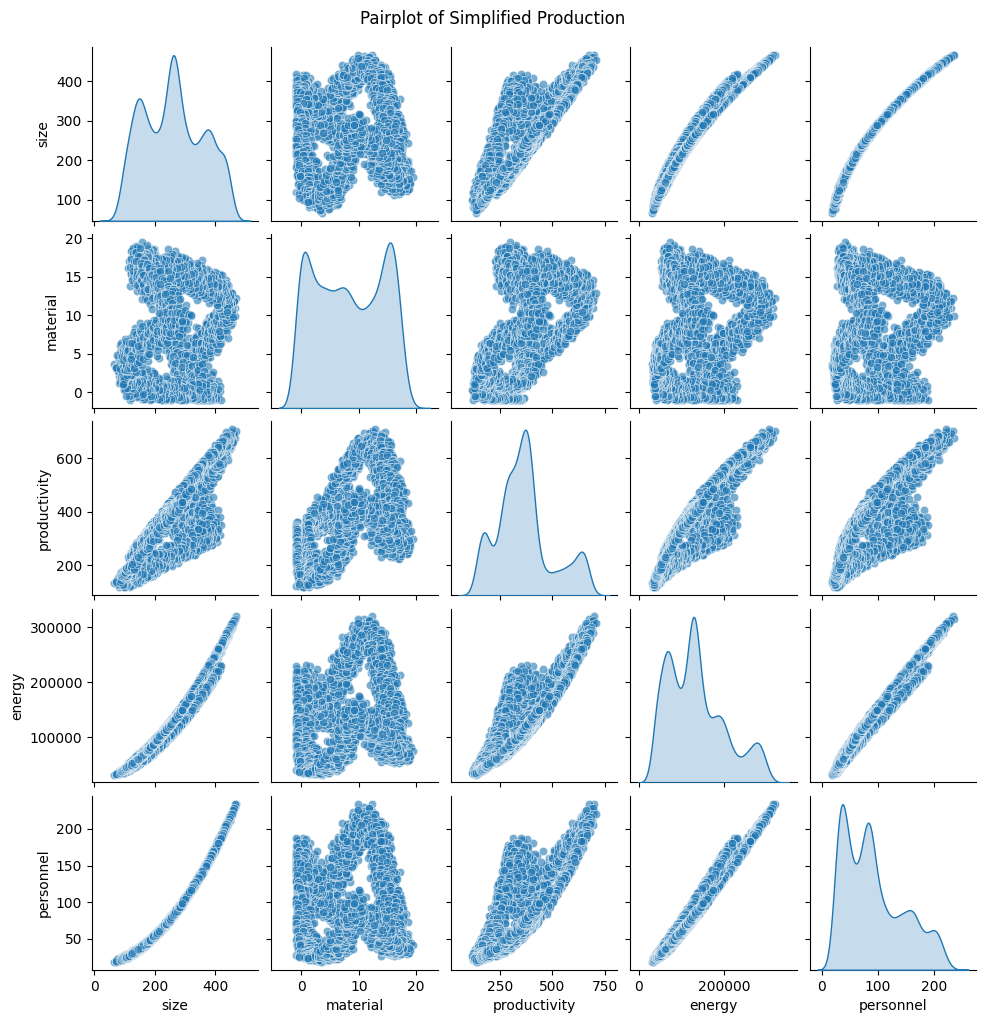

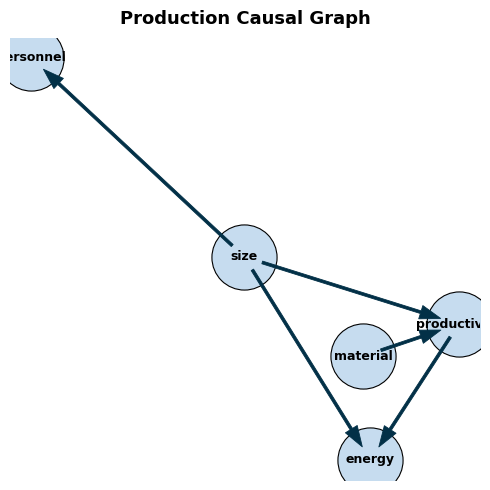

In [3]:


# Generate data and plot
synthetic_df = sim.simulation(n_samples=8000)

# Create pairplot
sns.pairplot(synthetic_df, diag_kind='kde', plot_kws={'alpha': 0.6}, height=2)
plt.suptitle("Pairplot of Simplified Production", y=1.02)
plt.show()

# Define variables and causal structure
var_names = ["personnel", "energy", "material", "size"]

causal_links = {
    "productivity": ["size", "material"],          
    "energy": ["productivity", "size"],
    "personnel": ["size"]
}

# Create and plot causal graph
G = ut.create_causal_graph(var_names, causal_links)
ut.plot_causal_graph(G, title="Production Causal Graph")

# Train and evaluate the models

In [4]:
model_configs

{'RandomForest': {'model_class': sklearn.ensemble._forest.RandomForestRegressor,
  'params': {'random_state': 42},
  'param_grid': {'n_estimators': [50, 100, 200, 500, 1000],
   'max_depth': [None, 5, 10, 20, 30, 50],
   'min_samples_split': [2, 5, 10, 15, 20],
   'min_samples_leaf': [1, 2, 4]}},
 'LinearRegression': {'model_class': sklearn.linear_model._base.LinearRegression,
  'param_grid': {'fit_intercept': [True, False], 'positive': [True, False]}},
 'MLP': {'model_class': model_wrappers.MLPRegressorWrapper,
  'param_grid': {'hidden_layer_sizes': [(50,),
    (100,),
    (50, 50),
    (100, 50),
    (100, 100)],
   'alpha': [0.001, 0.01, 0.1],
   'learning_rate': ['constant', 'adaptive']}},
 'XGBoost': {'model_class': model_wrappers.XGBRegressorWrapper,
  'params': {'random_state': 42},
  'param_grid': {'max_depth': [3, 5, 7, 10, 15],
   'learning_rate': [0.01, 0.05, 0.1, 0.3, 0.5],
   'n_estimators': [100, 200, 500, 1000],
   'subsample': [0.7, 0.85, 1.0]}},
 'GAM': {'model_class':

In [5]:

import time

# Define storage for equations
symbolic_equations = {
    "causal": {},      
    "traditional": {}  
}
trained_models = {}  
best_params = {}      # store best hyperparameters per model
results = []

# Define training, testing data and target
train_size = 8000
total_samples = int(train_size * 2)

data = sim.simulation(n_samples=total_samples, seed=42)
train_df, test_df = data[:train_size], data[train_size:]
target = "energy"
X_train = train_df.drop(columns=[target])
y_train = train_df[target]
X_test = test_df.drop(columns=[target])
y_test = test_df[target]

# Define the what-if analysis and generate the ground truth
intervention = 300
ground_truth_intervention = sim.simulation(n_samples=total_samples, seed=42, intervention=intervention)[:train_size]

# Train and evaluate every model
for name, cfg in model_configs.items():
    print(name)
    ModelClass = cfg["model_class"]
    params = cfg.get("params", {})
    param_grid = cfg.get("param_grid", None)

    # --- Causal version ---
    t0 = time.perf_counter()
    causal_models = ut.train_causal_models(train_df, G, ModelClass, model_params=params, param_grid=param_grid)
    causal_total_time = time.perf_counter() - t0

    causal_preds = ut.predict_causal(test_df, G, causal_models, what_if=False)
    rmse_c, wape_c, mae_c = ut.evaluate_metrics(test_df[target], causal_preds[target])
    results.append(["Causal", name, rmse_c, wape_c, mae_c, "Test", causal_total_time])
    
    if name == "SymbolicRegression":
        symbolic_equations["causal"][name] = {}
        for node, model in causal_models.items():
            try:
                equation = str(model.model.get_best()['equation'])
                equation = ut.round_numbers_in_string(equation)
                symbolic_equations["causal"][name][node] = equation
                print(f"[Causal {name}] Node '{node}': {equation}")
            except:
                symbolic_equations["causal"][name][node] = "No equation available"

    # --- Traditional ML version with hyperparameter tuning ---
    if param_grid:
        t0 = time.perf_counter()
        base_model = ModelClass(**params)
        grid_search = GridSearchCV(base_model, param_grid=param_grid, cv=4, n_jobs=-1, scoring='neg_mean_absolute_error')
        grid_search.fit(X_train, y_train)
        trad_total_time = time.perf_counter() - t0

        best_params[name] = grid_search.best_params_
        print(f"[GridSearchCV] Best params for Traditional '{name}': {grid_search.best_params_}")

        # Time fitting just the final best model once
        t1 = time.perf_counter()
        model = ModelClass(**{**params, **grid_search.best_params_})
        model.fit(X_train, y_train)
    else:
        t0 = time.perf_counter()
        model = ModelClass(**params)
        model.fit(X_train, y_train)
        trad_total_time = time.perf_counter() - t0
        best_params[name] = params  # fixed params (no tuning)

    y_pred = model.predict(X_test)
    rmse_t, wape_t, mae_t = ut.evaluate_metrics(y_test, y_pred)
    results.append(["Traditional", name, rmse_t, wape_t, mae_t, "Test", trad_total_time])
    
    if name == "SymbolicRegression":
        try:
            equation = str(model.model.get_best()['equation'])
            equation = ut.round_numbers_in_string(equation)
            symbolic_equations["traditional"][name] = equation
            print(f"[Traditional {name}] Target equation: {equation}")
        except:
            symbolic_equations["traditional"][name] = "No equation available"

    # --- Intervention scenario ---
    data_base = X_train.copy()
    data_base["size"] = intervention
    
    causal_preds_intervention = ut.predict_causal(data_base, G, causal_models, what_if=True)
    rmse_c_int, wape_c_int, mae_c_int = ut.evaluate_metrics(
        ground_truth_intervention[target], causal_preds_intervention[target]
    )
    results.append(["Causal", name, rmse_c_int, wape_c_int, mae_c_int, "Intervention", causal_total_time])

    y_pred_int = model.predict(data_base)
    rmse_t_int, wape_t_int, mae_t_int = ut.evaluate_metrics(
        ground_truth_intervention[target], y_pred_int
    )
    results.append(["Traditional", name, rmse_t_int, wape_t_int, mae_t_int, "Intervention", trad_total_time])

    trained_models[name] = {"causal": causal_models, "traditional": model}


RandomForest


[GridSearchCV] Best params for Traditional 'RandomForest': {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 1000}
LinearRegression
[GridSearchCV] Best params for Traditional 'LinearRegression': {'fit_intercept': True, 'positive': False}
MLP
[GridSearchCV] Best params for Traditional 'MLP': {'alpha': 0.1, 'hidden_layer_sizes': (100, 50), 'learning_rate': 'constant'}
XGBoost
[GridSearchCV] Best params for Traditional 'XGBoost': {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 1000, 'subsample': 1.0}
GAM
[GridSearchCV] Best params for Traditional 'GAM': {'lam': 0.01, 'n_splines': 10, 'spline_order': 3}
SymbolicRegression
Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#I

In [6]:

# Organize the results
results_df = pd.DataFrame(results, columns=["Model_Type", "Algorithm", "RMSE", "WAPE", "MAE", "Task", "train_time_total_s"])
results_df = results_df[["Model_Type", "Algorithm", "MAE", "RMSE", "WAPE", "Task", "train_time_total_s"]]
results_df = results_df.round(4)

if symbolic_equations["causal"]:
    print("\n--- CAUSAL MODELS ---")
    for model_name, node_equations in symbolic_equations["causal"].items():
        print(f"\n{model_name}:")
        for node, equation in node_equations.items():
            print(f"  {node}: {equation}")

if symbolic_equations["traditional"]:
    print("\n--- TRADITIONAL MODELS ---")
    for model_name, equation in symbolic_equations["traditional"].items():
        print(f"{model_name}: {equation}")

print("\n" + "="*80)
fmt = "{:,.4f}"
fmt_t = "{:,.4f}s"
display(
    results_df.style
    .format({"MAE": fmt, "RMSE": fmt, "WAPE": fmt, "train_time_total_s": fmt_t})
    .hide(axis="index")
)
print("\n" + "="*80)
print(trained_models)



--- CAUSAL MODELS ---

SymbolicRegression:
  personnel: (size * (size * 0.0010)) + 14.9813
  energy: (productivity * 130.0056) - (-9998.7280 - (size * size))
  productivity: (((log1p(material) + 1.7779) / 3.1755) * size) + 63.5110

--- TRADITIONAL MODELS ---
SymbolicRegression: ((personnel * 993.9957) + (productivity * 132.6140)) - 5526.7470



Model_Type,Algorithm,MAE,RMSE,WAPE,Task,train_time_total_s
Causal,RandomForest,"8,946.8788","12,131.4808",7.6354,Test,"1,147.5630s"
Traditional,RandomForest,"9,150.5342","12,308.9708",7.8092,Test,771.9398s
Causal,RandomForest,"1,097.4191","1,510.6087",0.6786,Intervention,"1,147.5630s"
Traditional,RandomForest,"14,013.0083","15,039.8835",8.6649,Intervention,771.9398s
Causal,LinearRegression,"11,134.4783","14,122.7942",9.5024,Test,0.1258s
Traditional,LinearRegression,871.7708,"1,091.9058",0.7440,Test,0.0529s
Causal,LinearRegression,"10,011.9696","10,259.0133",6.1909,Intervention,0.1258s
Traditional,LinearRegression,"67,071.1320","75,544.8099",41.4733,Intervention,0.0529s
Causal,MLP,"14,807.5726","26,018.5234",12.6371,Test,517.1330s
Traditional,MLP,"2,350.8373","3,917.5160",2.0063,Test,94.6138s



{'RandomForest': {'causal': {'personnel': RandomForestRegressor(max_depth=10, n_estimators=50, random_state=42), 'energy': RandomForestRegressor(max_depth=20, n_estimators=500, random_state=42), 'productivity': RandomForestRegressor(n_estimators=1000, random_state=42)}, 'traditional': RandomForestRegressor(max_depth=20, n_estimators=1000, random_state=42)}, 'LinearRegression': {'causal': {'personnel': LinearRegression(), 'energy': LinearRegression(positive=True), 'productivity': LinearRegression(positive=True)}, 'traditional': LinearRegression()}, 'MLP': {'causal': {'personnel': <model_wrappers.MLPRegressorWrapper object at 0x7fb6c857c250>, 'energy': <model_wrappers.MLPRegressorWrapper object at 0x7fb6c84b6650>, 'productivity': <model_wrappers.MLPRegressorWrapper object at 0x7fb6c93eda90>}, 'traditional': <model_wrappers.MLPRegressorWrapper object at 0x7fb6d37e7990>}, 'XGBoost': {'causal': {'personnel': <model_wrappers.XGBRegressorWrapper object at 0x7fb6c833f450>, 'energy': <model_wr

# Results

In [7]:
current_path = Path(__file__).resolve().parent if '__file__' in globals() else Path().resolve()
save_path = current_path.parent / "data" / "gold" / "evaluation_demonstration"
save_path.mkdir(parents=True, exist_ok=True)


In [8]:
results_df.columns

Index(['Model_Type', 'Algorithm', 'MAE', 'RMSE', 'WAPE', 'Task',
       'train_time_total_s'],
      dtype='object')

In [19]:

# Divide the results between test set and what-if analysis
df = results_df.copy()

columns_to_display = ['Type', 'Model', 'MAE', 'RMSE', 'WAPE']

df['Model_Type'] = df['Model_Type'].replace({'Causal': 'CML', 'Traditional': 'ML'})
df['Algorithm'] = df['Algorithm'].replace({
    'RandomForest': 'RForest',
    'SymbolicRegression': 'Symbolic',
    'XGBRegression': 'XGB',
    'LinearRegression': 'Linreg',
})

df.columns = ["Type", "Model", "MAE", "RMSE", "WAPE", "Task", "train_time_total_s"]

# Filter for Intervention task and drop Task column
intervention_df = df[df["Task"] == "Intervention"].drop(columns=["Task"]).sort_values(by=["MAE"]).copy()

# Filter for Test task and drop Task column
test_df = df[df["Task"] == "Test"].drop(columns=["Task"]).sort_values(by=["MAE"]).copy()

# Ensure numeric dtype (safe) and define formatter
for col in ["MAE", "RMSE", "WAPE", "train_time_total_s"]:
    intervention_df[col] = pd.to_numeric(intervention_df[col], errors="coerce")
    test_df[col] = pd.to_numeric(test_df[col], errors="coerce")

fmt = "{:,.4f}"
fmt_t = "{:,.4f}s"

# Display the Intervention table
print("Intervention Results:")
display(intervention_df[columns_to_display].style.format({"MAE": fmt, "RMSE": fmt, "WAPE": fmt,
                                      "train_time_total_s": fmt_t}).hide(axis="index"))
intervention_df.to_parquet(save_path / "intervention_restults.parquet", index=False, compression="snappy")


# Display the Test table
print("\nTest Results:")
display(test_df[columns_to_display].style.format({"MAE": fmt, "RMSE": fmt, "WAPE": fmt,
                              "train_time_total_s": fmt_t}).hide(axis="index"))
test_df.to_parquet(save_path / "test_results.parquet", index=False, compression="snappy")

# Display with times
display(intervention_df.style.format({"MAE": fmt, "RMSE": fmt, "WAPE": fmt,
                                      "train_time_total_s": fmt_t}).hide(axis="index"))
display(intervention_df.style.format({"MAE": fmt, "RMSE": fmt, "WAPE": fmt,
                                      "train_time_total_s": fmt_t}).hide(axis="index"))


Intervention Results:


Type,Model,MAE,RMSE,WAPE
CML,Symbolic,546.3665,685.4107,0.3378
CML,GAM,655.6439,818.8543,0.4054
CML,MLP,966.1252,"1,200.3433",0.5974
CML,RForest,"1,097.4191","1,510.6087",0.6786
CML,XGBoost,"1,199.0493","1,440.4911",0.7414
CML,Linreg,"10,011.9696","10,259.0133",6.1909
ML,RForest,"14,013.0083","15,039.8835",8.6649
ML,GAM,"16,522.3962","18,800.2062",10.2166
ML,XGBoost,"18,591.6119","20,493.5576",11.4961
ML,Linreg,"67,071.1320","75,544.8099",41.4733



Test Results:


Type,Model,MAE,RMSE,WAPE
CML,Symbolic,161.7618,201.7267,0.1381
CML,GAM,172.7371,221.7026,0.1474
ML,GAM,258.9799,328.4655,0.2210
ML,Linreg,871.7708,"1,091.9058",0.7440
ML,Symbolic,873.2224,"1,087.1806",0.7452
ML,MLP,"2,350.8373","3,917.5160",2.0063
ML,XGBoost,"4,014.8151","5,945.5700",3.4263
CML,XGBoost,"4,159.9224","6,194.8302",3.5502
CML,RForest,"8,946.8788","12,131.4808",7.6354
ML,RForest,"9,150.5342","12,308.9708",7.8092


Type,Model,MAE,RMSE,WAPE,train_time_total_s
CML,Symbolic,546.3665,685.4107,0.3378,"1,250.0253s"
CML,GAM,655.6439,818.8543,0.4054,2.6479s
CML,MLP,966.1252,"1,200.3433",0.5974,517.1330s
CML,RForest,"1,097.4191","1,510.6087",0.6786,"1,147.5630s"
CML,XGBoost,"1,199.0493","1,440.4911",0.7414,220.7898s
CML,Linreg,"10,011.9696","10,259.0133",6.1909,0.1258s
ML,RForest,"14,013.0083","15,039.8835",8.6649,771.9398s
ML,GAM,"16,522.3962","18,800.2062",10.2166,3.0790s
ML,XGBoost,"18,591.6119","20,493.5576",11.4961,146.7386s
ML,Linreg,"67,071.1320","75,544.8099",41.4733,0.0529s


Type,Model,MAE,RMSE,WAPE,train_time_total_s
CML,Symbolic,546.3665,685.4107,0.3378,"1,250.0253s"
CML,GAM,655.6439,818.8543,0.4054,2.6479s
CML,MLP,966.1252,"1,200.3433",0.5974,517.1330s
CML,RForest,"1,097.4191","1,510.6087",0.6786,"1,147.5630s"
CML,XGBoost,"1,199.0493","1,440.4911",0.7414,220.7898s
CML,Linreg,"10,011.9696","10,259.0133",6.1909,0.1258s
ML,RForest,"14,013.0083","15,039.8835",8.6649,771.9398s
ML,GAM,"16,522.3962","18,800.2062",10.2166,3.0790s
ML,XGBoost,"18,591.6119","20,493.5576",11.4961,146.7386s
ML,Linreg,"67,071.1320","75,544.8099",41.4733,0.0529s


In [10]:


# --- Save best hyperparameters ---
params_path = save_path / "best_hyperparameters.json"
serialisable_params = {
    model_name: {k: (list(v) if isinstance(v, tuple) else v) for k, v in p.items()}
    for model_name, p in best_params.items()
}
with open(params_path, "w") as f:
    json.dump(serialisable_params, f, indent=2)

# --- Save best models ---
models_dir = save_path / "models"
models_dir.mkdir(parents=True, exist_ok=True)

for model_name, model_dict in trained_models.items():
    # Traditional (tuned) model
    joblib.dump(model_dict["traditional"], models_dir / f"{model_name}_traditional.pkl")
    # Causal models (one per node)
    for node, causal_model in model_dict["causal"].items():
        joblib.dump(causal_model, models_dir / f"{model_name}_causal_{node}.pkl")

print("Files written:")
for f in sorted(models_dir.iterdir()):
    print(f"  {f.name}")


Files written:
  GAM_causal_energy.pkl
  GAM_causal_personnel.pkl
  GAM_causal_productivity.pkl
  GAM_traditional.pkl
  LinearRegression_causal_energy.pkl
  LinearRegression_causal_personnel.pkl
  LinearRegression_causal_productivity.pkl
  LinearRegression_traditional.pkl
  MLP_causal_energy.pkl
  MLP_causal_personnel.pkl
  MLP_causal_productivity.pkl
  MLP_traditional.pkl
  RandomForest_causal_energy.pkl
  RandomForest_causal_personnel.pkl
  RandomForest_causal_productivity.pkl
  RandomForest_traditional.pkl
  SymbolicRegression_causal_energy.pkl
  SymbolicRegression_causal_personnel.pkl
  SymbolicRegression_causal_productivity.pkl
  SymbolicRegression_traditional.pkl
  XGBoost_causal_energy.pkl
  XGBoost_causal_personnel.pkl
  XGBoost_causal_productivity.pkl
  XGBoost_traditional.pkl


# Shap for the ML XGBoost

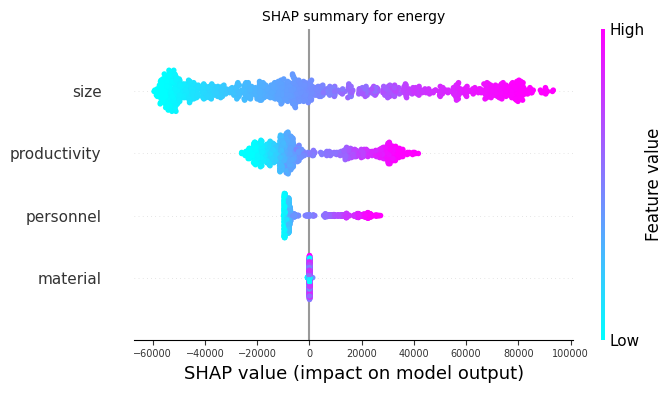

In [11]:
rf_model = trained_models["XGBoost"]["traditional"]

# Create SHAP explainer for tree-based model
explainer = shap.TreeExplainer(rf_model.model)

# Sample data for SHAP
X_sample = X_train.sample(1000, random_state=42)

# Compute SHAP values
shap_values = explainer.shap_values(X_sample)

# Create Explanation object for beeswarm
explanation = shap.Explanation(values=shap_values, data=X_sample.values, feature_names=X_sample.columns)

# Make base fonts a bit smaller
plt.rcParams.update({"font.size": 9})

# Create 1 subplot (since it's one traditional model)
fig, ax = plt.subplots(1, 1, figsize=(7, 4))

# Beeswarm plot
shap.plots.beeswarm(explanation, ax=ax, show=False, plot_size=None, color=plt.get_cmap("cool",))

# Title and smaller x-axis tick labels
ax.set_title('SHAP summary for energy', fontsize=10)
ax.tick_params(axis='x', labelsize=7)   # make x-axis values smaller
ax.tick_params(axis='y', labelsize=11)   # optional: slightly smaller y labels

plt.tight_layout()
# plt.savefig('visuals/traditional_shap_beeswarm.svg', format='svg', bbox_inches='tight')
plt.savefig('visuals/traditional_shap_beeswarm.svg', format='svg', bbox_inches='tight', dpi=1000)
plt.savefig('visuals/traditional_shap_beeswarm.pdf', format='pdf', bbox_inches='tight', dpi=500)
plt.show()


# Partial dependence plot for the ML GAM

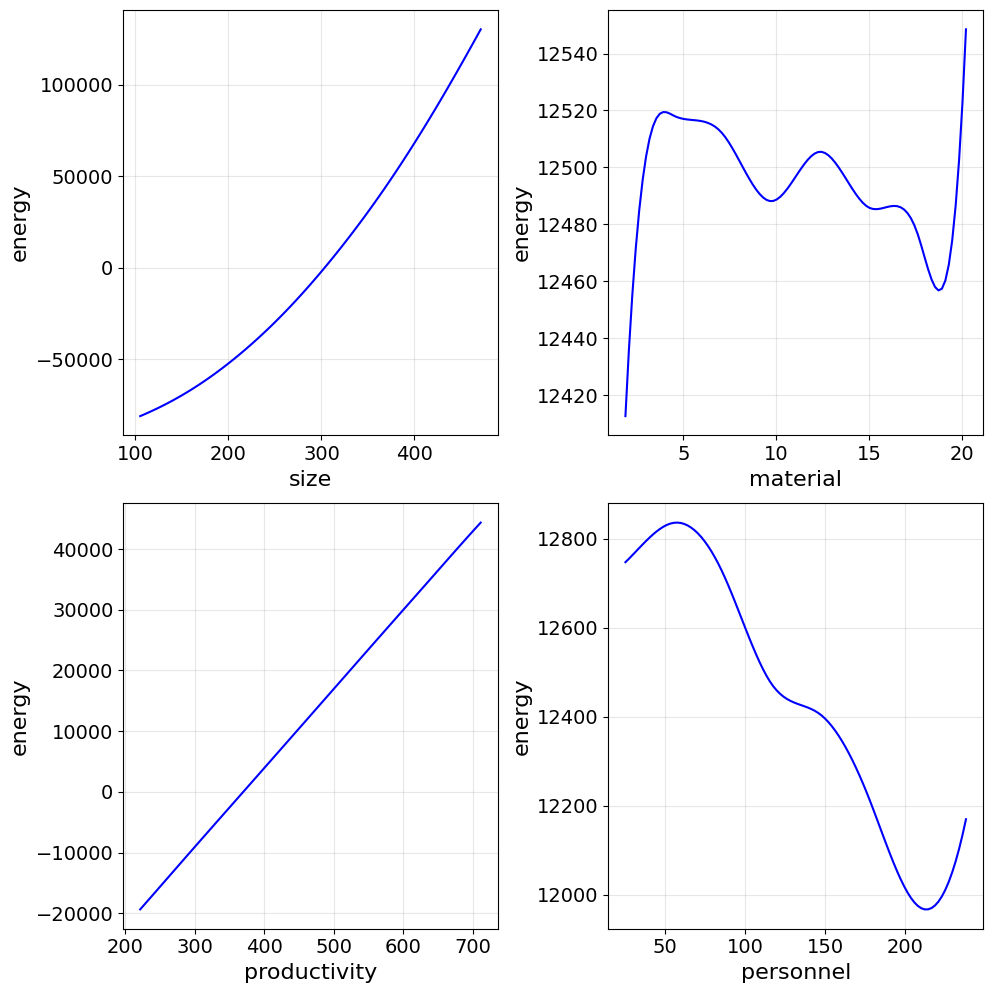

In [12]:

features = list(X_train.columns)
n_features = len(features)

for name, model_dict in trained_models.items():
    if name != "GAM":
        continue  # Only plot for GAM
    
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))  # 2x2 grid
    
    gam_model = model_dict["traditional"].model  # Access the underlying LinearGAM
    
    for i, feature in enumerate(features):
        try:
            # Generate grid for this term
            XX = gam_model.generate_X_grid(term=i)
            pdep = gam_model.partial_dependence(term=i, X=XX)
            
            ax = axes.flat[i]  # Use flat indexing for 2x2 grid
            ax.plot(XX[:, i], pdep, color='blue')
            ax.set_xlabel(feature, fontsize=16)
            ax.set_ylabel('energy', fontsize=16)
            ax.tick_params(axis='both', which='major', labelsize=14)
            ax.grid(True, alpha=0.3)
            
            # Format x-axis in scientific notation for 'energy'
            if feature == "energy":
                ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
        except Exception as e:
            ax = axes.flat[i]
            ax.text(0.5, 0.5, f'Error: {e}', ha='center', va='center', transform=ax.transAxes, fontsize=12)
    
    plt.tight_layout()
    plt.savefig('visuals/partial_dependence_plots_traditional.pdf', format='pdf', bbox_inches='tight', dpi=500)
    plt.show()

# Shap for the causal XGBoost

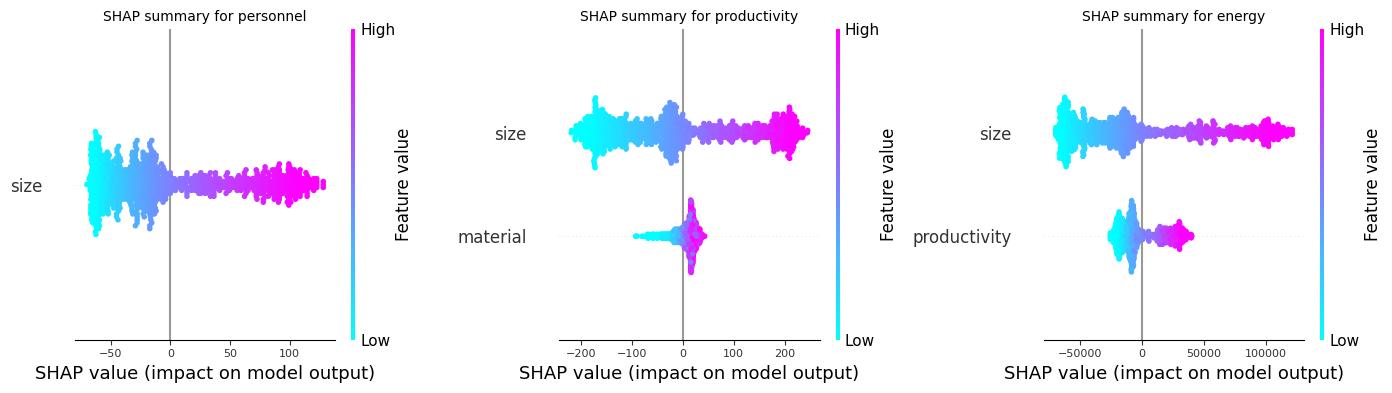

In [13]:

causal_models = trained_models["XGBoost"]["causal"]

# Nodes to plot
nodes = ['personnel', 'productivity', 'energy']

# Create 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, node in enumerate(nodes):
    model = causal_models[node]
    explainer = shap.TreeExplainer(model.model)
    
    # Get the parents (features) for this node
    parents = list(G.predecessors(node))
    X_node = train_df[parents].sample(1000)
    
    # Compute SHAP values
    shap_values = explainer.shap_values(X_node)
    
    # Create Explanation object for beeswarm
    explanation = shap.Explanation(values=shap_values, data=X_node.values, feature_names=X_node.columns)
    
    # Beeswarm plot in the subplot (fix: add plot_size=None)
    shap.plots.beeswarm(explanation, ax=axes[i], show=False, plot_size=None, color=plt.get_cmap('cool'))
    axes[i].set_title(f'SHAP summary for {node}', fontsize=10)
    axes[i].tick_params(axis='x', which='major', labelsize=8) 
    axes[i].tick_params(axis='y', which='major', labelsize=12) 


plt.tight_layout()
plt.savefig('visuals/causal_shap_summary_causal.svg', format='svg', bbox_inches='tight', dpi=1000)
plt.savefig('visuals/causal_shap_summary_causal.pdf', format='pdf', bbox_inches='tight', dpi=500)
plt.show()

# Partial Dependence plot for the causal GAM

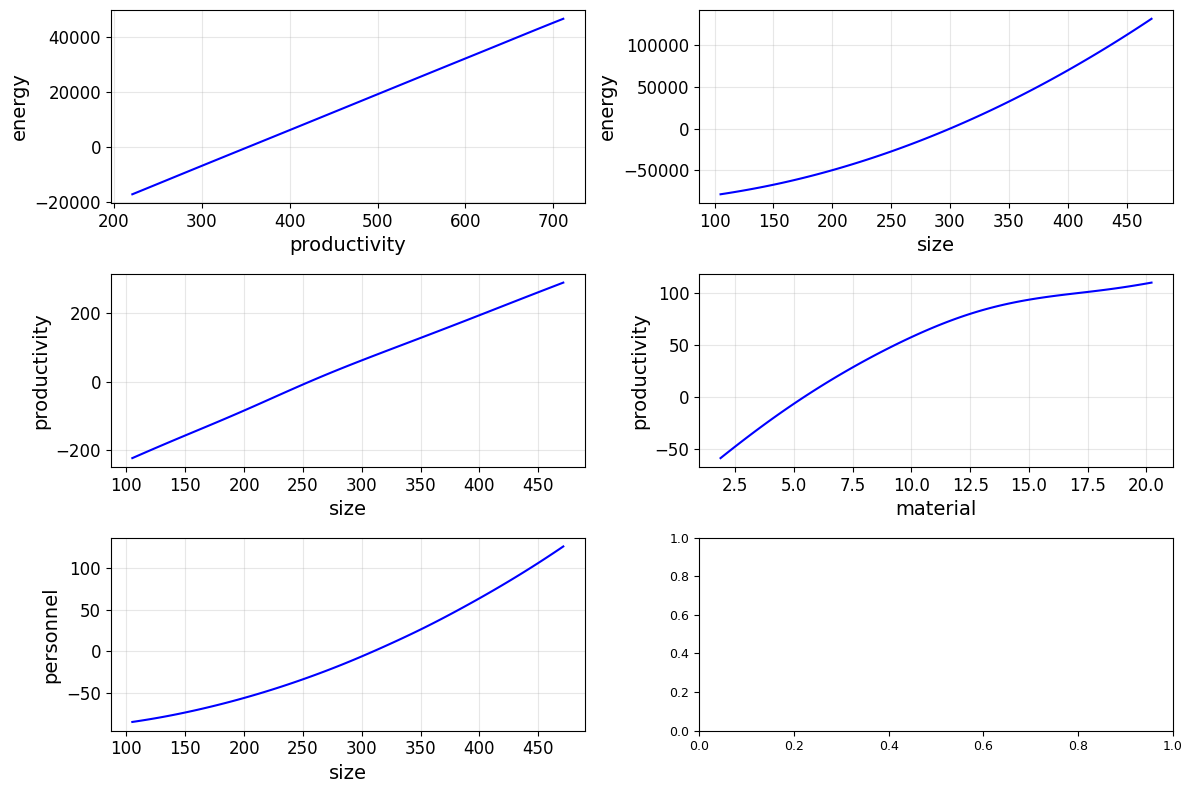

In [14]:


for name, model_dict in trained_models.items():
    if name != "GAM":
        continue  # Only plot for GAM
    
    causal_models = model_dict["causal"]
    
    # Nodes to plot
    nodes = [ 'energy', 'productivity', 'personnel']
    
    # Create a 3x2 grid for 6 subplots
    fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 8))
    axes = axes.flatten()  # Flatten to 1D array for easy indexing
    
    plot_idx = 0  # Index for the current subplot
    
    for node in nodes:
        gam_wrapper = causal_models[node]
        gam_model = gam_wrapper.model  # Access the underlying LinearGAM
        parents = list(G.predecessors(node))
        
        for feature in parents:
            try:
                # Generate grid for this term
                XX = gam_model.generate_X_grid(term=parents.index(feature))
                pdep = gam_model.partial_dependence(term=parents.index(feature), X=XX)
                
                ax = axes[plot_idx]
                ax.plot(XX[:, parents.index(feature)], pdep, color='blue')
                ax.set_xlabel(feature, fontsize=14)
                ax.set_ylabel(node, fontsize=14)
                ax.tick_params(axis='both', which='major', labelsize=12)
                ax.grid(True, alpha=0.3)
                
                # Format x-axis in scientific notation for 'energy'
                if feature == "energy":
                    ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
                
                plot_idx += 1
            except Exception as e:
                ax = axes[plot_idx]
                ax.text(0.5, 0.5, f'Error: {e}', ha='center', va='center', transform=ax.transAxes, fontsize=12)
                plot_idx += 1
    
    plt.tight_layout()
    plt.savefig('visuals/causal_partial_dependence_plots.pdf', format='pdf', bbox_inches='tight', dpi=500)
    plt.show()


# Show symbolic equations

In [15]:
if symbolic_equations["causal"]:
    print("\n--- CAUSAL MODELS ---")
    for model_name, node_equations in symbolic_equations["causal"].items():
        print(f"\n{model_name}:")
        for node, equation in node_equations.items():
            print(f"  {node}: {equation}")

if symbolic_equations["traditional"]:
    print("\n--- TRADITIONAL MODELS ---")
    for model_name, equation in symbolic_equations["traditional"].items():
        print(f"\n{model_name}:")
        print(f"  Target equation: {equation}")



--- CAUSAL MODELS ---

SymbolicRegression:
  personnel: (size * (size * 0.0010)) + 14.9813
  energy: (productivity * 130.0056) - (-9998.7280 - (size * size))
  productivity: (((log1p(material) + 1.7779) / 3.1755) * size) + 63.5110

--- TRADITIONAL MODELS ---

SymbolicRegression:
  Target equation: ((personnel * 993.9957) + (productivity * 132.6140)) - 5526.7470


# Show causal graph

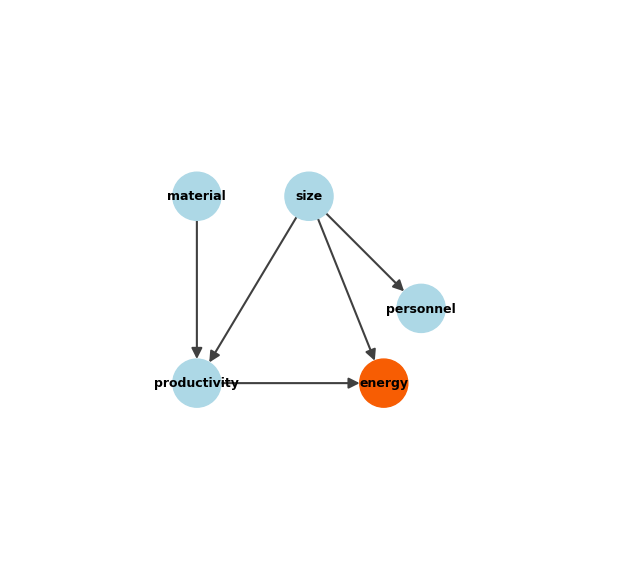

In [16]:



def draw_custom_graph(ax, edges, positions, labels=None, y_threshold=0.7, node_size=1200):
    G = nx.DiGraph()
    G.add_edges_from(edges)

    # Node colors: orange for 'energy', light blue otherwise
    node_colors = ["#F75D03" if node == 'energy' else 'lightblue' for node in G.nodes()]

    if labels is None:
        labels = {node: node for node in G.nodes()}

    nx.draw(
        G, pos=positions, ax=ax,
        with_labels=False,
        node_size=node_size,
        node_color=node_colors,
        edge_color='#404040',
        arrows=True,
        arrowsize=16,
        width=1.5
    )

    # Draw node names inside the nodes
    for node in G.nodes():
        x, y = positions[node]
        ax.text(x, y, node, ha='center', va='center',
                fontsize=9, fontweight='bold', color='black')

    # Set tight limits based on node positions with a small padding
    xs = [p[0] for p in positions.values()]
    ys = [p[1] for p in positions.values()]
    min_x, max_x = min(xs), max(xs)
    min_y, max_y = min(ys), max(ys)
    pad_x = max(0.05, (max_x - min_x) * 0.12)
    pad_y = max(0.05, (max_y - min_y) * 0.12)
    ax.set_xlim(min_x - pad_x, max_x + pad_x)
    ax.set_ylim(min_y - pad_y, max_y + pad_y)

    ax.set_aspect('equal', 'box')
    ax.axis('off')


# ==========================================================
# Create one subplot with smaller canvas
fig, ax = plt.subplots(1, 1, figsize=(6, 6))  # smaller figure

# ---------- LEFT GRAPH ----------
edges_original = [
    ('size', 'productivity'),
    ('size', 'personnel'),
    ('size', 'energy'),
    ('material', 'productivity'),
    ('productivity', 'energy'),
]
positions_left = {
    'size': (0.93, 0.9),
    'productivity': (0.9, 0.85),
    'personnel': (0.96, 0.87),
    'energy': (0.95, 0.85),
    'material': (0.9, 0.9),
}

draw_custom_graph(ax, edges_original, positions_left, labels=None, node_size=1200)

plt.tight_layout(pad=0.08)
plt.savefig('visuals/static_SCM_example_no_formula.pdf', bbox_inches='tight', pad_inches=0.02, dpi=400, format='pdf')
plt.show()
